# Crank Nicolson Method for Heat Equation

Solve:
\begin{align*}
  u_t  &= \alpha^2 u_{xx} \\
u(x,0) &= g(x)\\
u(0,t) &= A \\
u(L,t) &= B \\
(t,x) &\in \mathbb{R}^{+} \times (0,L)
\end{align*}


Consider a discretization $x_i, t_j$, then the solution $u$ is discretized by the matrix $U$ with the correspondence rule:

$$ U_i^j = u(x_i, t_j) $$

Thus, the algorithm to follow is:

$$ - \lambda U_{i+1}^{j+1} + (1+2\lambda) U_i^{j+1} - \lambda U_{i-1}^{j+1} = \lambda U_{i+1}^j + (1-2\lambda) U_i^j + \lambda U_{i-1}^j, $$

Where $i = 1, \cdots, n-1, \, j = 1, \cdots, m-1$ and $\lambda = \dfrac{\alpha^2 k}{2 h^2}$

Notice that from the boundary conditions one has for any $i,j$:
\begin{align*}
U_i^0 &= u(x_i, t_0) = u(x_i, 0) = g(x_i)\\
U_0^j &= A \\
U_{n}^j &= B\\
\end{align*}

## Example
For the sake of simplicty, let us consider $g(x) = \sin(\pi x), \, L = 1, \, \alpha = 1$ and $A = B = 0$. Thus, the solution for this problem is $u(x,t) = \sin(\pi x) \exp(-\pi^2 t)$ and the equation to be solved is:
\begin{align*}
u_t &= u_{xx},\\
u(x,0) &= \sin (\pi x)\\
u (0,t) &= 0\\
u (1,t) &= 0 \\
(t,x) &\in \mathbb{R}^{+} \times (0,1)
\end{align*}

And for discretization purposes, we will also assume that $0 < t < 1$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from scipy.linalg import solve_banded
from scipy import sparse

from utils.visualization import plot_diff_matrices
from utils.calculus import discretize
from utils.linalg import tridiag

def solution(x, t) -> np.float64:
    xx = np.sin(np.pi * x)
    tt = np.exp(- np.pi ** 2 * t)
    return xx * tt

def g(x) -> np.float64:
    return np.sin(np.pi * x)

L = T = alpha = np.float64(1)
A = B = np.float64(0)

Number of points to be discretized and some constants

In [2]:
n = np.int8(10)                 # space discretization
m = np.int16(500)               # time discretization
xx = np.linspace(0, L, n)
tt = np.linspace(0, T, m)
h = L/n
k = T/m
lambda_ = (alpha**2 * k) / (2 * h**2)

### Tridiagonal system
In Linear Algebra terms, the system to solve is:

$$

\begin{pmatrix}
1+2\lambda & -\lambda & 0 & \cdots & 0 \\
-\lambda & 1+2\lambda & -\lambda & \cdots & 0 \\
0 & -\lambda & 1+2\lambda & \cdots & 0 \\
\vdots & & & \ddots & \vdots \\
0 & 0 & 0 & \cdots & 1+2\lambda
\end{pmatrix} 
\cdot 
\begin{pmatrix} 
U_1^{j+1} \\
\vdots \\
U_{n-1}^{j+1} \\
\end{pmatrix}
= 
\begin{pmatrix}
1-2\lambda & \lambda & 0 & \cdots & 0 \\
\lambda & 1-2\lambda & \lambda & \cdots & 0 \\
0 & \lambda & 1-2\lambda & \cdots & 0 \\
\vdots & & & \ddots & \vdots \\
0 & 0 & 0 & \cdots & 1-2\lambda
\end{pmatrix} 
\cdot 
\begin{pmatrix} 
U_1^{j} \\
\vdots \\
U_{n-1}^{j} \\
\end{pmatrix}

$$

With $U^0 = g(x)$, $U_0^j = A$, and $U_n^j = B$. 

In [4]:
def gen_ab(
        n: int, 
        param: float
) -> np.ndarray:
    band = np.full(n-1, -param)
    diag = np.full(n, 1+2*param)
    ab = np.vstack((
        np.append(0, band),
        diag,
        np.append(band, 0)
    ))
    return ab

In [19]:
def solver(
        xx: np.ndarray, 
        m: int,
        param: float, 
) -> np.ndarray:
    
    n, = xx.shape

    # n-2 since we are not including boundary conditions
    ab = gen_ab(n-2, param)
    m_right = tridiag(n-2, 1-2*param, param)
    res = np.empty([n-2, m])

    res[:, 0] = g(xx)[1:-1]
    for j in range(m-2):
        right = m_right.dot(res[:, j])
        res[:, j+1] = solve_banded((1, 1), ab, right)
    
    boundary_a = np.full(m, A)
    boundary_b = np.full(m, B)
    result = np.vstack((boundary_a, res, boundary_b))
    return result


mat = solver(xx, m, lambda_)

### TODO: Implement super-mega solver
The system from the previous section can be still simplified:
$$
\begin{pmatrix}
-\Lambda_2 & \Lambda_1 & 0 & \cdots & 0 \\
0 & -\Lambda_2 & \Lambda_1 & \cdots & 0 \\
0 & 0 & -\Lambda_2 & \cdots & 0 \\
\vdots & & & \ddots & \vdots \\
0 & 0 & 0 & \cdots & -\Lambda_2
\end{pmatrix} \cdot U'
= 0
$$
Where $U' = ({U'}^j)$ and the system is derived from $\Lambda_1 {U'}^{j+1}= \Lambda_2 {U'}^j$ considering ${U'}^j = (U_i^j)_{i=1, \cdots, m-1}$ (concatenated in a single 1D vector). This improves performance since no recursive iteration is needed in contrast to `solver`.

# Results

This shows how close these matrices are in each $t_i$.

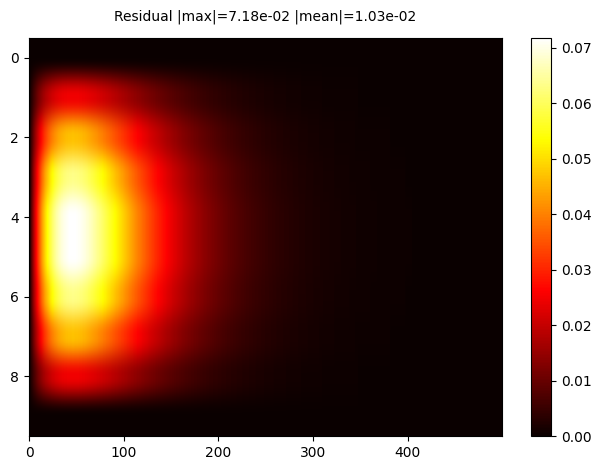

In [32]:
arr = discretize(solution, xx, tt)
fig = plot_diff_matrices(arr, mat)

Generate an animation of the solution vs the discretization for all values of $t_i$.

In [ ]:
fig, ax = plt.subplots()
ax.set(xlim=[0, 1], ylim=[0, 1], xlabel='time', ylabel='u(x, t)')

# initialize first plots
[line] = ax.plot(xx, solution(xx, tt[0]), color='blue')
scatter = ax.scatter(xx, mat[:, 0], color='red')


def set_err_title(frame: int, err: float) -> None:
    title = f"Average error @ t={tt[frame]:.2f}: {err:.5e}"
    ax.set_title(title) 


def update(frame: int) -> None:
    t_= tt[frame]
    sol_ = solution(xx, t_)
    mat_data = mat[:, frame]
    data = np.stack([xx, mat_data]).T
    
    line.set_ydata(sol_)
    scatter.set_offsets(data)
    
    err = np.mean(np.abs(sol_ - mat_data))
    set_err_title(frame, err)


set_err_title(0, 0.)
frames, = tt.shape
frames /= 2
ani = animation.FuncAnimation(fig=fig, func=update, frames=frames)
ani.save('./data/here.mp4', fps=24)